# Reproducing Figure 6 of Tsigaridis et al. 2025 (GMD, ROCKE-3D 2.0)

> "Box-and-whisker plot of net planetary radiation (`net_rad_planet`) in W m$^{-2}$ for all ocean configurations following balancing. The last 100 years of simulations were used for analysis."

Data source (NASA GISS publication supplement for this paper):
https://portal.nccs.nasa.gov/GISS_modelE/ROCKE-3D/publication-supplements/Tsigaridis2025GMD-planet_2.0/

Each `planet_2.0` configuration directory there holds 100 annual-mean `aij`/`aijl` NetCDF files (years 4000-4099, or the equivalent last-100-year window for that run). This notebook pulls the `net_rad_planet_hemis` global-mean value out of each year's `aij` file for a set of configurations and reproduces the box-and-whisker plot.

Config -> directory mapping below is copied verbatim from that directory's `README.txt` (two entries there have a paper-name typo, `P2Gxq*` where the target directory is clearly `P2Sxq*`; corrected here -- the directory names, which is what actually matters for fetching, are untouched).

In [1]:
# --- Environment self-check ---
# Some environments end up with a numpy 2.x / matplotlib<3.8 ABI mismatch
# (matplotlib compiled against numpy 1.x). This cell detects and fixes that
# in-place for the current kernel before we rely on plotting. --user keeps
# the fix scoped to your own site-packages, not the shared module tree.
import subprocess, sys

def ensure_plotting_works():
    try:
        import matplotlib.pyplot as plt  # noqa: F401
        return
    except Exception as e:
        print(f"matplotlib import failed ({e!r}); upgrading matplotlib in this kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "-q", "-U", "matplotlib"])
    import importlib
    import matplotlib
    importlib.reload(matplotlib)

ensure_plotting_works()

import matplotlib.pyplot as plt
import netCDF4 as nc
print("matplotlib", plt.matplotlib.__version__)
print("netCDF4", nc.__version__)

matplotlib 3.10.3
netCDF4 1.7.2


In [2]:
import re
import concurrent.futures
from pathlib import Path
from urllib.request import urlopen, Request

BASE_URL = "https://portal.nccs.nasa.gov/GISS_modelE/ROCKE-3D/publication-supplements/Tsigaridis2025GMD-planet_2.0"
CACHE_DIR = Path("./rocke3d_cache")

# paper_name -> directory_name, planet_2.0 simulations, from README.txt
CONFIGS = {
    "P2GApF40": "P2GAF40_002",   "P2GApM40": "P2GAM40_008",
    "P2GAqF40": "P2GAqF40_002",  "P2GAqM40": "P2GAqM40_002",
    "P2GAoF40": "P2GAoF40_005",  "P2GAoM40": "P2GAoM40_009",

    "P2GxpF40": "P2GxF40_005",   "P2GxpM40": "P2GxM40_008",
    "P2GxqF40": "P2GxqF40_001",  "P2GxqM40": "P2GxqM40_001",
    "P2GxoF40": "P2GxoF40_001",  "P2GxoM40": "P2GxoM40_001",

    "P2GNpF40": "P2GNF40_005",   "P2GNpM40": "P2GNM40_003",
    "P2GNqF40": "P2GNqF40_002",  "P2GNqM40": "P2GNqM40_002",
    "P2GNoF40": "P2GNoF40_002",  "P2GNoM40": "P2GNoM40_002",

    "P2SApF40": "P2SAF40_017",   "P2SApM40": "P2SAM40_019",
    "P2SAqF40": "P2SAqF40_004",  "P2SAqM40": "P2SAqM40_005",
    "P2SAoF40": "P2SAoF40_004",  "P2SAoM40": "P2SAoM40_003",

    "P2SxpF40": "P2SxF40_007",   "P2SxpM40": "P2SxM40_014",
    "P2SxqF40": "P2SxqF40_002",  "P2SxqM40": "P2SxqM40_002",
    "P2SxoF40": "P2SxoF40_002",  "P2SxoM40": "P2SxoM40_002",

    "P2SNpF40": "P2SNF40_006",   "P2SNpM40": "P2SNM40_011",
    "P2SNqF40": "P2SNqF40_004",  "P2SNqM40": "P2SNqM40_004",
    "P2SNoF40": "P2SNoF40_004",  "P2SNoM40": "P2SNoM40_004",
}

def list_remote_years(directory: str, paper_name: str):
    """The .nc filename suffix is the paper name (verified against the server),
    even where the directory name itself drops letters (e.g. P2SApM40 lives in
    directory P2SAM40_019)."""
    url = f"{BASE_URL}/{directory}/"
    with urlopen(Request(url, headers={"User-Agent": "curl/8"})) as resp:
        html = resp.read().decode("utf-8", "ignore")
    pat = re.compile(r'href="(ANN(\d+)\.aij' + re.escape(paper_name) + r'\.nc)"')
    hits = sorted((int(year), fname) for fname, year in pat.findall(html))
    return hits

def fetch_file(directory: str, fname: str) -> Path:
    dest = CACHE_DIR / directory / fname
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists() or dest.stat().st_size == 0:
        url = f"{BASE_URL}/{directory}/{fname}"
        with urlopen(Request(url, headers={"User-Agent": "curl/8"})) as resp, open(dest, "wb") as out:
            out.write(resp.read())
    return dest

def global_mean_net_rad_planet(path: Path) -> float:
    ds = nc.Dataset(path)
    try:
        return float(ds.variables["net_rad_planet_hemis"][2])  # [SH, NH, global]
    finally:
        ds.close()

def collect_config(paper_name: str, n_years: int = 100, workers: int = 6):
    directory = CONFIGS[paper_name]
    years = list_remote_years(directory, paper_name)
    if not years:
        raise RuntimeError(f"No files found for {paper_name} ({directory})")
    last_n = years[-n_years:]
    print(f"{paper_name} ({directory}): {len(last_n)} years [{last_n[0][0]}-{last_n[-1][0]}]")

    def _one(item):
        _, fname = item
        local = fetch_file(directory, fname)
        return global_mean_net_rad_planet(local)

    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(_one, last_n))

## Pick which configurations to include

`N_YEARS = 20` below gives a quick first run (a few MB per config). Set `N_YEARS = 100` to exactly match the paper's "last 100 years" methodology once you've confirmed the pipeline works -- that downloads ~7 MB x 100 per config, so the full 36-config M40+F40 sweep is on the order of 25 GB.

`SELECTED` defaults to the 12 medium-resolution (M40) configs across all three ocean types and all radiation/atmosphere combos. Swap in `list(CONFIGS)` for the full 36-config figure (M40 + F40).

In [3]:
N_YEARS = 20
SELECTED = [c for c in CONFIGS if c.endswith("M40")]

data = {}
for paper_name in SELECTED:
    try:
        data[paper_name] = collect_config(paper_name, n_years=N_YEARS)
    except Exception as e:
        print(f"WARNING: skipping {paper_name}: {e}")

P2GApM40 (P2GAM40_008): 20 years [2480-2499]
P2GAqM40 (P2GAqM40_002): 20 years [2480-2499]
P2GAoM40 (P2GAoM40_009): 20 years [3980-3999]
P2GxpM40 (P2GxM40_008): 20 years [2480-2499]
P2GxqM40 (P2GxqM40_001): 20 years [2480-2499]
P2GxoM40 (P2GxoM40_001): 20 years [3980-3999]
P2GNpM40 (P2GNM40_003): 20 years [2480-2499]
P2GNqM40 (P2GNqM40_002): 20 years [2480-2499]
P2GNoM40 (P2GNoM40_002): 20 years [3980-3999]
P2SApM40 (P2SAM40_019): 20 years [2180-2199]
P2SAqM40 (P2SAqM40_005): 20 years [2580-2599]
P2SAoM40 (P2SAoM40_003): 20 years [4080-4099]
P2SxpM40 (P2SxM40_014): 20 years [2180-2199]
P2SxqM40 (P2SxqM40_002): 20 years [2580-2599]
P2SxoM40 (P2SxoM40_002): 20 years [4080-4099]
P2SNpM40 (P2SNM40_011): 20 years [2180-2199]
P2SNqM40 (P2SNqM40_004): 20 years [2780-2799]
P2SNoM40 (P2SNoM40_004): 20 years [4280-4299]


/explore/nobackup/people/gtamkin/.nccstmp/ipykernel_969128/3217132538.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels, showfliers=True)


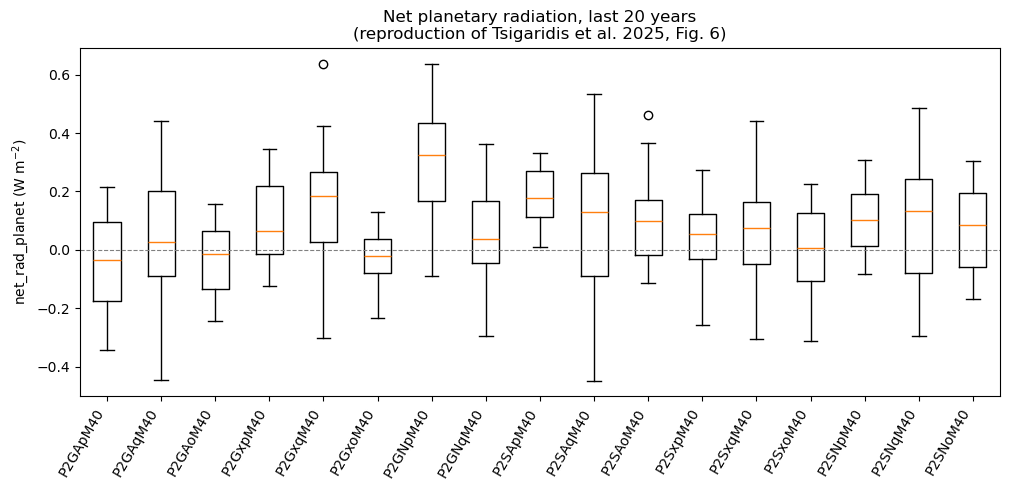

In [4]:
labels = list(data.keys())
series = [data[k] for k in labels]

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(labels)), 5))
ax.boxplot(series, labels=labels, showfliers=True)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylabel("net_rad_planet (W m$^{-2}$)")
ax.set_title(f"Net planetary radiation, last {N_YEARS} years\n(reproduction of Tsigaridis et al. 2025, Fig. 6)")
plt.xticks(rotation=60, ha="right")
fig.tight_layout()
fig.savefig("figure6_reproduction.png", dpi=150)
plt.show()